In [51]:
# IMPORTANT:
#   Whenever you start a new colab runtime, use the following code to download
#   the training dataset onto the runtime local storage.
#   This should take ~3-5 mins for the whole dataset.
#   You can then load data from the local storage (/content/data) into your colab
#   notebook using the `h5py` library (see example below).
from huggingface_hub import hf_hub_download
hf_hub_download(repo_id="benmoseley/ese-dl-2024-25-group-project", filename="train.h5", repo_type="dataset", local_dir="data")
hf_hub_download(repo_id="benmoseley/ese-dl-2024-25-group-project", filename="events.csv", repo_type="dataset", local_dir="data")

'data/events.csv'

## Libraries

In [52]:
# General Libraries
import os
import time
import random
import io

# Numerical & Data Handling
import numpy as np
import pandas as pd
import h5py

# Machine Learning & Deep Learning
import torch
import tensorflow as tf

# PyTorch Utilities
from torch.utils.data import DataLoader, Subset
from torch import nn, optim

# TensorFlow / Keras - Model & Layers
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Input, Conv3D, ConvLSTM2D, ConvLSTM3D, Conv3DTranspose,
    Dropout, BatchNormalization, Activation, Add, Multiply,
    GlobalAveragePooling3D, Dense, Reshape
)

# TensorFlow / Keras - Training Utilities
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Scikit-learn
from sklearn.model_selection import train_test_split

# Visualization
import matplotlib.pyplot as plt
from PIL import Image
from IPython import display

# Utility Libraries
from itertools import cycle
from scipy.ndimage import zoom
from tqdm.keras import TqdmCallback

# Google Colab (if needed)
try:
    from google.colab import drive  # Only required if using Google Drive storage
except ImportError:
    pass  # Ignore if not using Google Colab

## Data preprocessing utilities and pipeline -> SLIDING WINDOW

In [53]:
def extract_event_ids(file_path):
    """
    Extract all event IDs from the HDF5 file.

    Parameters:
        file_path (str): Path to the HDF5 file.
    Returns:
        list: List of event IDs.

    """
    with h5py.File(file_path, "r") as f:
        return list(f.keys())

def standard_normalize(data):
    """
    Standard normalization: (data - mean) / std.
    Avoid division by zero by adding a small epsilon to std.

    Parameters:
        data (numpy.ndarray): Input data.
    Returns:
        numpy.ndarray: Normalized data.
    """
    mean = np.mean(data)
    std = np.std(data)
    return (data - mean) / (std + 1e-8)

def mse_ssim_loss(alpha=0.7, beta=0.3):
    """
    Combined MSE + SSIM loss function.

    Parameters:
        alpha (float): Weight for the MSE component.
        beta (float): Weight for the SSIM component.
    Returns:
        Callable loss function.
    """
    def loss(y_true, y_pred):
        # Compute MSE loss
        mse_loss = tf.reduce_mean(tf.square(y_true - y_pred))

        # Compute SSIM loss (1 - mean SSIM)
        ssim_value = tf.image.ssim(y_true, y_pred, max_val=1.0)  # Normalize inputs to [0, 1]
        ssim_loss = 1 - tf.reduce_mean(ssim_value)

        # Combine MSE and SSIM losses
        return alpha * mse_loss + beta * ssim_loss

    return loss

def min_max_normalize(data):
    """
    Applies Min-Max Normalization to scale data into a specified range.

    Parameters:
        data (numpy.ndarray): Input data.
    Returns:
        numpy.ndarray: Normalized data.

    """
    min_val = np.min(data)
    max_val = np.max(data)
    return (data - min_val) / (max_val - min_val)

# This below is the data generator but selects randomly one index to start the count of 24 from. Then selects frist 12 and next 12 frames.
# def dynamic_data_generator(file_path, event_ids, batch_size=8, input_length=12, output_length=12, target_shape=(384, 384)):
#     """
#     Dynamically loads and processes data from HDF5 file for training and validation.
#     """
#     event_cycle = cycle(event_ids)  # Cycle through event IDs indefinitely
#     np.random.shuffle(event_ids)  # Shuffle event IDs at the start

#     with h5py.File(file_path, "r") as f:
#         while True:
#             X_batch, Y_batch = [], []

#             # Select a batch of event IDs
#             unique_event_ids = [next(event_cycle) for _ in range(batch_size)]

#             for event_id in unique_event_ids:
#                 if event_id not in f:
#                     raise ValueError(f"Event ID {event_id} not found in file.")

#                 # Load dataset (Only 'vil' is used; extend for multiple features if needed)
#                 vil = f[event_id]["vil"][:]

#                 # Standardize the dataset
#                 vil = min_max_normalize(vil)

#                 # Determine the total number of valid frames for sliding windows
#                 min_frames = vil.shape[0]
#                 total_windows = (min_frames - input_length - output_length) // 12 + 1

#                 if total_windows <= 0:
#                     continue  # Skip if not enough frames

#                 # Randomly select a starting sliding window index
#                 window_idx = np.random.randint(0, total_windows)
#                 start_frame = window_idx * 12

#                 # Define input and output frame slices
#                 input_frames = slice(start_frame, start_frame + input_length)
#                 output_frames = slice(start_frame + input_length, start_frame + input_length + output_length)

#                 # Process inputs
#                 X_resized = np.array([
#                     upsample(vil[frame], target_shape)  # Resize each frame
#                     for frame in range(input_frames.start, input_frames.stop)
#                 ])  # Shape: (input_length, height, width)

#                 # Process outputs
#                 Y_resized = np.array([
#                     upsample(vil[frame], target_shape)
#                     for frame in range(output_frames.start, output_frames.stop)
#                 ])  # Shape: (output_length, height, width)

#                 # Reshape data for Conv3D:
#                 # Move the time axis to the second dimension and add a channel axis
#                 X_final = X_resized[:, :, :, np.newaxis]  # (input_length, height, width, 1)
#                 Y_final = Y_resized[:, :, :, np.newaxis]  # (output_length, height, width, 1)

#                 X_batch.append(X_final)
#                 Y_batch.append(Y_final)

#             # Convert to NumPy arrays and return batch in shape (batch, time, height, width, channels)
#             X_batch = np.array(X_batch)  # Shape: (batch_size, input_length, height, width, 1)
#             Y_batch = np.array(Y_batch)  # Shape: (batch_size, output_length, height, width, 1)

#             yield X_batch, Y_batch

def dynamic_data_generator(file_path, event_ids, batch_size=16, input_length=12, output_length=12, target_shape=(384, 384)):
    """
    Dynamically loads and processes data from HDF5 file for training and validation.
    Applies a sliding window to extract sequences (12 input + 12 output) from 36-frame events.

    Parameters:
        file_path (str): Path to the HDF5 file.
        event_ids (list): List of event IDs.
        batch_size (int): Number of samples per batch.
        input_length (int): Number of input frames.
        output_length (int): Number of output frames.
        target_shape (tuple): Target shape for resizing.
    Returns:
        tuple: Batch of input and output data.

    """
    event_cycle = cycle(event_ids)  # Cycle through event IDs indefinitely
    np.random.shuffle(event_ids)  # Shuffle event IDs at the start

    with h5py.File(file_path, "r") as f:
        while True:
            X_batch, Y_batch = [], []
            count = 0  # Track how many samples are added

            # Select a batch of event IDs
            unique_event_ids = [next(event_cycle) for _ in range(batch_size)]

            for event_id in unique_event_ids:
                if event_id not in f:
                    raise ValueError(f"Event ID {event_id} not found in file.")

                # Load dataset (Only 'vil' is used; extend for multiple features if needed)
                vil = f[event_id]["vil"][:]  # Shape: (36, H, W)

                # Standardize the dataset
                vil = min_max_normalize(vil)

                # Ensure we have at least 36 frames
                if vil.shape[0] < 36:
                    continue  # Skip events with fewer frames

                # Apply Sliding Window: Move from 1st frame (index 0) to 13th frame (index 12)
                for start_frame in range(13):  # Sliding window range: 0 to 12
                    input_frames = slice(start_frame, start_frame + input_length)  # 12 frames
                    output_frames = slice(start_frame + input_length, start_frame + input_length + output_length)  # Next 12 frames

                    # Process inputs
                    X_resized = np.array([
                        upsample(vil[frame], target_shape)  # Resize each frame
                        for frame in range(input_frames.start, input_frames.stop)
                    ])  # Shape: (input_length, height, width)

                    # Process outputs
                    Y_resized = np.array([
                        upsample(vil[frame], target_shape)
                        for frame in range(output_frames.start, output_frames.stop)
                    ])  # Shape: (output_length, height, width)

                    # Reshape data for Conv3D: Move time axis to second dimension and add a channel axis
                    X_final = X_resized[:, :, :, np.newaxis]  # (12, height, width, 1)
                    Y_final = Y_resized[:, :, :, np.newaxis]  # (12, height, width, 1)

                    X_batch.append(X_final)
                    Y_batch.append(Y_final)
                    count += 1  # Increase sample count

                    # Stop adding more samples if batch size is reached
                    if count >= batch_size:
                        break  # Stop sliding window iterations

                # Stop adding more events if batch size is reached
                if count >= batch_size:
                    break

            # Convert to NumPy arrays and return batch in shape (batch_size, time, height, width, channels)
            yield np.array(X_batch), np.array(Y_batch)

## Training utilities and pipeline

In [54]:
def mount_drive_and_set_save_path():
    """Mounts Google Drive and sets up the save path."""
    drive.mount('/content/drive')
    save_path = "/content/drive/My Drive/models/"
    os.makedirs(save_path, exist_ok=True)  # Create folder if it doesn't exist
    return save_path

def compute_steps(train_ids, val_ids, batch_size):
    """Computes steps per epoch for training and validation."""
    train_steps = len(train_ids) // batch_size
    val_steps = len(val_ids) // batch_size
    return train_steps, val_steps

def train_model(model, train_generator, val_generator, epochs, train_steps, val_steps):
    """Trains the model with tqdm progress bar and returns training history."""

    model.compile(optimizer="adam", loss=mse_ssim_loss(alpha=0.7, beta=0.3), metrics=["mae"])

    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=epochs,
        steps_per_epoch=train_steps,
        validation_steps=val_steps,
        callbacks=[TqdmCallback()]  # Add tqdm progress bar
    )
    return history

def save_model(model, save_path, model_name="conv3DLSTM_lightning_prediction.keras"):
    """Saves the trained model to Google Drive."""
    model_save_path = os.path.join(save_path, model_name)
    model.save(model_save_path)
    print(f"Model saved successfully at: {model_save_path}")

def plot_training_history(history):
    """Plots training and validation loss curves."""
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.title('Training vs Validation Loss')
    plt.show()


In [46]:
def training_pipeline(model, train_generator, val_generator, train_ids, val_ids, epochs, batch_size=8):
    """Runs the entire training pipeline: setup, training, saving, and plotting."""

    # Ensure save path is set
    save_path = mount_drive_and_set_save_path()

    # Compute training steps
    train_steps, val_steps = compute_steps(train_ids, val_ids, batch_size)

    # Train model
    history = train_model(model, train_generator, val_generator, epochs, train_steps, val_steps)

    # Save the trained model
    save_model(model, save_path)

    # Plot training loss history
    plot_training_history(history)


## Testing utilities and pipeline

In [47]:
def generate_predictions(model, test_generator):
    """
    Fetches a batch from the test generator and generates predictions.

    Returns:
        - X_test_sample: Input sequence (past frames)
        - Y_test_sample: Ground truth future sequence
        - Y_pred_sample: Model predicted future sequence
    """
    # Get one batch from test generator
    X_test_batch, Y_test_batch = next(test_generator)

    # Make predictions
    Y_pred = model.predict(X_test_batch)  # Output shape: (batch, 12, 384, 384, 1)

    # Select the first sample from the batch
    X_test_sample = X_test_batch[0]  # Shape: (12, 384, 384, 1)
    Y_test_sample = Y_test_batch[0]  # Shape: (12, 384, 384, 1)
    Y_pred_sample = Y_pred[0]  # Shape: (12, 384, 384, 1)

    return X_test_sample, Y_test_sample, Y_pred_sample

def plot_prediction_comparison(X_input, Y_real, Y_pred, num_frames=12):
    """
    Plot the first num_frames of input, real vs predicted sequences side by side.

    - First row: Input frames (past observations)
    - Second row: Real future frames (ground truth)
    - Third row: Predicted future frames
    """
    fig, axes = plt.subplots(3, num_frames, figsize=(20, 8))

    for i in range(num_frames):
        # Input sequence (past)
        axes[0, i].imshow(X_input[i, :, :, 0], cmap="turbo")
        axes[0, i].set_title(f"Input Frame {i+1}")
        axes[0, i].axis("off")

        # Real sequence (ground truth)
        axes[1, i].imshow(Y_real[i, :, :, 0], cmap="turbo")
        axes[1, i].set_title(f"Real Frame {i+1}")
        axes[1, i].axis("off")

        # Predicted sequence
        axes[2, i].imshow(Y_pred[i, :, :, 0], cmap="turbo")
        axes[2, i].set_title(f"Pred Frame {i+1}")
        axes[2, i].axis("off")

    plt.suptitle("Input vs Real vs Predicted Lightning Frames")
    plt.show()

def prediction_pipeline(model, test_generator):
    """
    Generates predictions and plots the results using a trained model.

    Parameters:
        model: Trained Keras model.
        test_generator: Data generator for testing.


    Returns:
        None

    """
    X_input, Y_real, Y_pred = generate_predictions(model, test_generator)
    plot_prediction_comparison(X_input, Y_real, Y_pred)

In [66]:
def compute_saliency_maps(model, X_input, Y_pred):
    """
    Computes saliency maps using TensorFlow's GradientTape.
    """
    X_input_tf = tf.convert_to_tensor(X_input, dtype=tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(X_input_tf)
        Y_pred_tf = model(X_input_tf)

    gradients = tape.gradient(Y_pred_tf, X_input_tf)

    return np.abs(gradients.numpy())


def plot_prediction_comparison_2(X_input, Y_real, Y_pred, saliency_maps, num_frames=12):
    """
    Plot input frames, real vs predicted sequences, and saliency maps.

    - First row: Input frames (past observations)
    - Second row: Real future frames (ground truth)
    - Third row: Predicted future frames
    - Fourth row: Saliency maps highlighting important input regions
    """
    fig, axes = plt.subplots(4, num_frames, figsize=(20, 10))

    for i in range(num_frames):
        # Input sequence (past)
        axes[0, i].imshow(X_input[i, :, :, 0], cmap="turbo")  # Removed .cpu()
        axes[0, i].set_title(f"Input Frame {i+1}")
        axes[0, i].axis("off")

        # Real sequence (ground truth)
        axes[1, i].imshow(Y_real[i, :, :, 0], cmap="turbo")  # Removed .cpu()
        axes[1, i].set_title(f"Real Frame {i+1}")
        axes[1, i].axis("off")

        # Predicted sequence
        axes[2, i].imshow(Y_pred[i, :, :, 0], cmap="turbo")  # Removed .cpu()
        axes[2, i].set_title(f"Pred Frame {i+1}")
        axes[2, i].axis("off")

        # Saliency Map
        axes[3, i].imshow(saliency_maps[i, :, :, 0], cmap="turbo")  # Removed .cpu()
        axes[3, i].set_title(f"Saliency {i+1}")
        axes[3, i].axis("off")

    plt.suptitle("Input vs Real vs Predicted vs Saliency Maps", fontsize=14)
    plt.show()


def prediction_pipeline_2(model, test_generator):
    """
    Generates predictions, computes saliency maps, and plots the results.

    Parameters:
        model: Trained Keras model.
        test_generator: Data generator for testing.


    Returns:
        None

    """
    X_input, Y_real, Y_pred = generate_predictions(model, test_generator)

    X_input = torch.from_numpy(X_input)
    Y_pred = torch.from_numpy(Y_pred)

    # Compute saliency maps
    saliency_maps = compute_saliency_maps(model, X_input.unsqueeze(0), Y_pred.unsqueeze(0)).squeeze(0)

    # Plot all results including saliency maps
    plot_prediction_comparison_2(X_input, Y_real, Y_pred, saliency_maps)

## Data Splitting and Loading

The data normalization approach chosen was min-max normalization. Unlike standardization (z-score normalization), which transforms data based on mean and standard deviation, min-max normalization maintains relative differences between values and does not assume a Gaussian distribution.

For training and validation, dynamic generators were used as dataloaders, with two possible strategies considered. The first approach involved random start index selection, where a single starting index was randomly chosen within each event, which consists of 36 frames. From that point, 24 consecutive frames were selected, with the first 12 frames used as inputs and the next 12 frames used as targets for the model. This method introduces some variation in training while ensuring diverse sequences are extracted from each event. The second approach was a sliding window method, which captured all possible 12-frame input/output pairs within the 36-frame event. This method ensured complete coverage of every possible training pair, maximizing the available data but potentially introducing redundancy. Ultimately, the final choice of dataloader was based on balancing computer memory, dataset diversity, and model performance. We ended up using the second option, data augmentation for our model.

The dataset was split into 80% for training and 20% for validation, a common practice.


In [56]:
# # Path to your HDF5 file
# file_path = "data/train.h5"

# # Extract event IDs from the HDF5 file
# event_ids = extract_event_ids(file_path)

# # Split the event IDs into training, validation, and test sets
# train_ids = event_ids[:640]  # First 640 for training
# val_ids = event_ids[640:720]  # Next 80 for validation
# test_ids = event_ids[720:]  # Remaining for testing

# # Create generators for training, validation, and testing
# train_generator = dynamic_data_generator(file_path, train_ids, batch_size=16, input_length=12, output_length=12)
# val_generator = dynamic_data_generator(file_path, val_ids, batch_size=16, input_length=12, output_length=12)
# test_generator = dynamic_data_generator(file_path, test_ids, batch_size=16, input_length=12, output_length=12)

# # Check the output shape for debugging (Get one batch from the train_generator)
# X_batch, Y_batch = next(train_generator)

# # Print the shapes of the batches (input and output)
# print("Input batch shape:", X_batch.shape)
# print("Output batch shape:", Y_batch.shape)

Input batch shape: (16, 12, 384, 384, 1)
Output batch shape: (16, 12, 384, 384, 1)


In [70]:
# Path to your HDF5 file
file_path = "data/train.h5"

# Extract event IDs from the HDF5 file
event_ids = extract_event_ids(file_path)

# Split the event IDs into training, validation, and test sets
train_ids = event_ids[:640]  # First 640 for training
val_ids = event_ids[640:]  # Next for validation

# Create generators for training, validation, and testing
train_generator = dynamic_data_generator(file_path, train_ids, batch_size=16, input_length=12, output_length=12)
val_generator = dynamic_data_generator(file_path, val_ids, batch_size=16, input_length=12, output_length=12)

# Check the output shape for debugging (Get one batch from the train_generator)
X_batch, Y_batch = next(train_generator)

# Print the shapes of the batches (input and output)
print("Input batch shape:", X_batch.shape)
print("Output batch shape:", Y_batch.shape)

Input batch shape: (16, 12, 384, 384, 1)
Output batch shape: (16, 12, 384, 384, 1)


## Models Considered Discussion

The task at hand involves predicting 12 future frames from 12 previous frames, requiring the model to capture both spatial and temporal dependencies. Given the spatiotemporal nature of the problem, we explored multiple architectures, leveraging convolutional networks and recurrent structures.

Convolutional layers serve as the primary building blocks for image-based tasks due to their effectiveness in extracting spatial features. However, our problem extends beyond static image processing—it requires modeling temporal relationships between frames. To address this, two main modeling strategies were explored:
- U-Net-Based Approach: This approach implicitly captures temporal dependencies by pooling together frame-wise spatial representations. While effective in some cases, it may not fully capture complex spatiotemporal dynamics.
- CNN-LSTM Hybrid Model: A widely used model for spatiotemporal tasks, this approach combines convolutional layers for spatial feature extraction with LSTMs (or ConvLSTMs) to model sequential dependencies. https://rsree.ise.illinois.edu/Machine_Learning_&_Data_Analytics_files/ACPR_2019_paper_242.pdf

The Unet model can be found in branch task1. Loss achieved at 5 epochs was 0.048334. Images for the first frames predicted showed quite a bit of resemblance to the real ones, but it was clear that latter frames were prediced less well. In order to remedy this, an explicit wat to capture temporal dependencies was chosen.



## Simple Conv3D+LSMT

In [ ]:
# Define input shape (batch, depth, height, width, channels)
input_shape = (12, 384, 384, 1)  # Excluding batch size

# Build Conv3D + ConvLSTM2D Model
model_conv3DLSTM = Sequential([
    # Encoding (Downsampling)
    Conv3D(16, (3, 3, 3), padding='same', activation='relu', strides=(1, 2, 2), input_shape=input_shape),
    Dropout(0.2),

    Conv3D(32, (3, 3, 3), padding='same', activation='relu', strides=(1, 2, 2)),
    Dropout(0.2),

    Conv3D(64, (3, 3, 3), padding='same', activation='relu'),
    Dropout(0.3),

    # ConvLSTM for temporal sequence learning
    ConvLSTM2D(64, (3, 3), padding="same", return_sequences=True, activation="relu"),
    Dropout(0.3),

    ConvLSTM2D(32, (3, 3), padding="same", return_sequences=True, activation="relu"),
    Dropout(0.2),

    # Decoding (Upsampling)
    Conv3DTranspose(32, (3, 3, 3), strides=(1, 2, 2), padding='same', activation='relu'),
    Dropout(0.2),

    Conv3DTranspose(16, (3, 3, 3), strides=(1, 2, 2), padding='same', activation='relu'),
    Dropout(0.2),

    # Output layer: Predicts 12 frames
    Conv3D(1, (1, 1, 1), padding='same', activation='linear')
])

# Loss function = mse_ssim_loss
model_conv3DLSTM.compile(optimizer="adam", loss=mse_ssim_loss(alpha=0.7, beta=0.3), metrics=["mae"])


# Show model summary
model_conv3DLSTM.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv3d (Conv3D)                      │ (None, 12, 192, 192, 16)    │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 12, 192, 192, 16)    │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_1 (Conv3D)                    │ (None, 12, 96, 96, 32)      │          13,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 12, 96, 96, 32)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_2 (Conv3D)                    │ (None, 12, 96, 96, 64)      │          55,360 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 12, 96, 96, 64)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_lstm2d (ConvLSTM2D)             │ (None, 12, 96, 96, 64)      │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 12, 96, 96, 64)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_lstm2d_1 (ConvLSTM2D)           │ (None, 12, 96, 96, 32)      │         110,720 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 12, 96, 96, 32)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_transpose (Conv3DTranspose)   │ (None, 12, 192, 192, 32)    │          27,680 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 12, 192, 192, 32)    │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_transpose_1 (Conv3DTranspose) │ (None, 12, 384, 384, 16)    │          13,840 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 12, 384, 384, 16)    │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_3 (Conv3D)                    │ (None, 12, 384, 384, 1)     │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 517,089 (1.97 MB)

 Trainable params: 517,089 (1.97 MB)

 Non-trainable params: 0 (0.00 B)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

Epoch 1/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 107s 1s/step - loss: 0.0856 - mae: 0.0416 - val_loss: 0.0566 - val_mae: 0.0245
Epoch 2/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - loss: 0.0683 - mae: 0.0342 - val_loss: 0.0527 - val_mae: 0.0239
Epoch 3/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 87s 1s/step - loss: 0.0642 - mae: 0.0294 - val_loss: 0.0516 - val_mae: 0.0231
Epoch 4/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - loss: 0.0599 - mae: 0.0286 - val_loss: 0.0533 - val_mae: 0.0232
Epoch 5/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - loss: 0.0585 - mae: 0.0267 - val_loss: 0.0534 - val_mae: 0.0231
Epoch 6/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - loss: 0.0575 - mae: 0.0267 - val_loss: 0.0477 - val_mae: 0.0205
Epoch 7/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - loss: 0.0556 - mae: 0.0248 - val_loss: 0.0439 - val_mae: 0.0195
Epoch 8/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - loss: 0.0548 - mae: 0.0249 - val_loss: 0.0449 - val_mae: 0.0180
Epoch 9/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - loss: 0.0557 - mae:

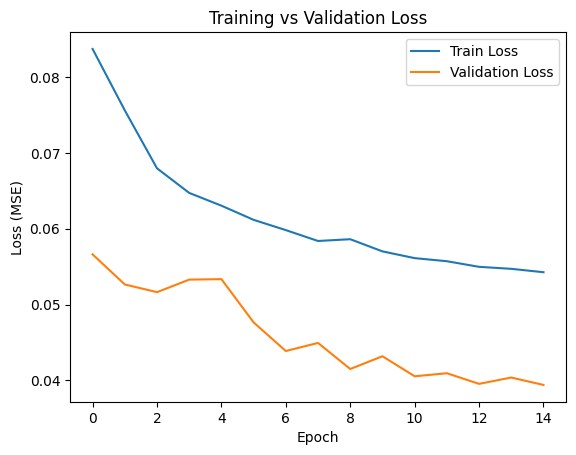

In [ ]:

epochs = 15  # Define the number of training epochs
training_pipeline(model_conv3DLSTM, train_generator, val_generator, train_ids, val_ids, epochs, batch_size=8)

One of the major reasons for val loss being lowert is due to the training loss being calculated during training for each epoch, while validation loss is calculated after the training is done, so the model already has previous knowledge about what kind of data you are using and essentially its distribution.

https://ai.stackexchange.com/questions/43383/validation-loss-is-always-lower-than-training-loss-whatever-i-try

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


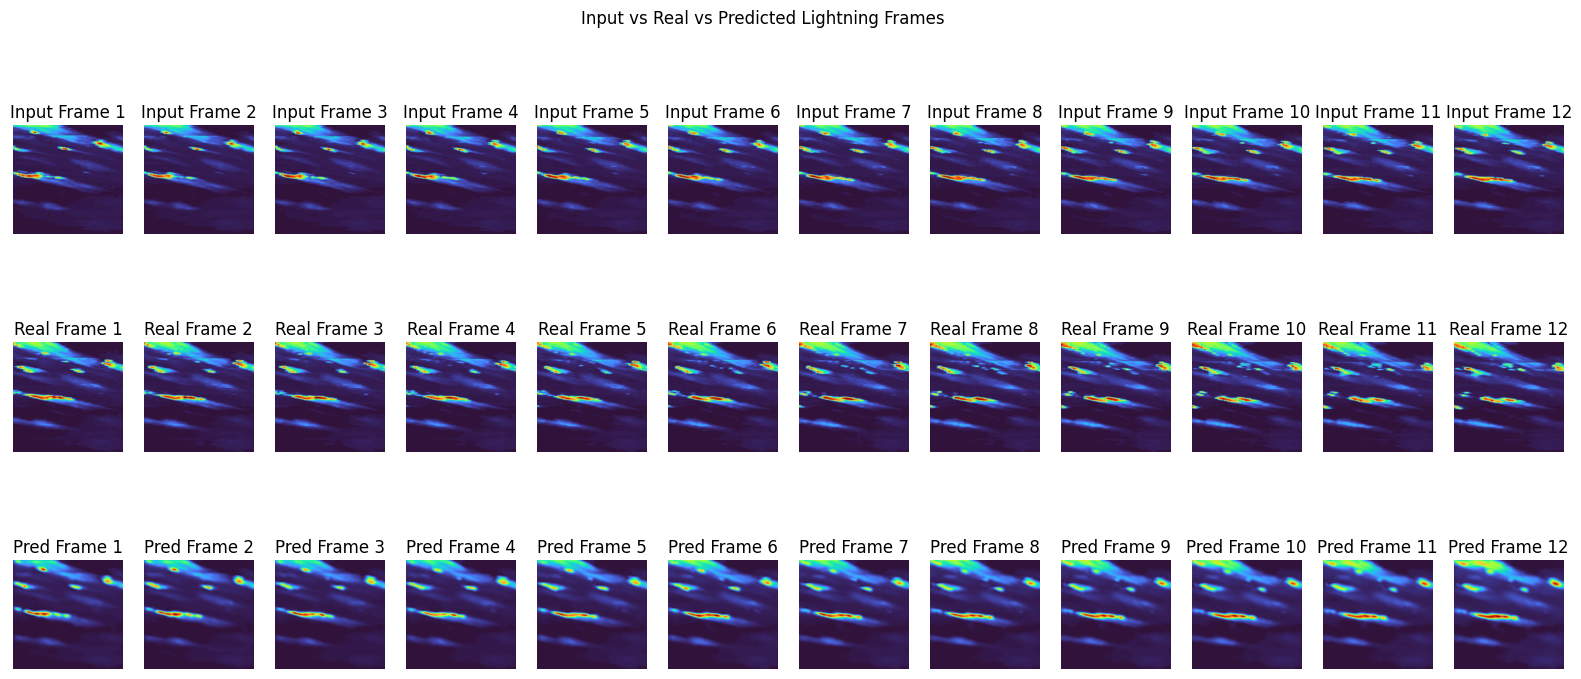

In [ ]:
model_baseline = tf.keras.models.load_model("/content/drive/MyDrive/models/conv3DLSTM_lightning_prediction.keras", compile=False)
prediction_pipeline(model_baseline, test_generator)

1.	Loss of fine-grained details in predicted frames, leading to blurriness.
2.	Temporal inconsistency in the predictions, meaning the model struggles to fully understand motion.


## Optimising

### Discussion

- Depth Scaling:
Increasing the number of ConvLSTM layers to 8 had the most significant impact on improving performance. This is because deeper architectures allow the model to extract progressively richer spatiotemporal features. Since ConvLSTMs are designed to remember patterns over time, additional layers improved their ability to learn long-range dependencies.
- Stride Adjustments:
Adjusting strides in convolutional layers is a known method for downsampling spatial dimensions, reducing computational costs. However, in our case, modifying strides did not significantly impact performance. This is likely because stride changes primarily affect spatial feature extraction rather than sequence modeling, which is the core challenge in this problem.
- Batch Normalization:
While batch normalization is beneficial in CNNs by stabilizing gradients and improving convergence, it showed limited impact on our ConvLSTM model.
- Residual Connections:
Residual connections help mitigate vanishing gradient issues in very deep networks. However, in our case, they did not yield significant improvements. One possible explanation is that ConvLSTMs already have gated mechanisms that control information flow, reducing the necessity for explicit residual links.
- Attention Mechanisms:
Inspired by transformer-based models for weather forecasting, attention layers were considered to selectively focus on the most important spatial-temporal features. However, in earlier experiments, attention blocks did not lead to significant improvements. This may be because attention mechanisms are more useful in cases where the input has complex dependencies across distant frames, whereas our dataset may already contain strong local correlations.
- Learning Rate Scheduling & Batch Size Adjustments:
A dynamic learning rate scheduler (ReduceLROnPlateau) was implemented to prevent stagnation, but in some cases, it led to overly linear loss trends, suggesting that the learning rate was reducing too soon and preventing deeper exploration of the loss landscape.

A batch size of 8/16 was chosen for a balance between gradient stability and generalization while avoiding excessive memory use. The hybrid loss (MSE + SSIM) ensures both pixel-wise accuracy (MSE) and structural integrity (SSIM), preventing overly smooth predictions. SSIM helps preserve sharp edges and textures, crucial for maintaining spatial coherence across frames, while MSE alone would lead to blurry outputs.

### Bigger paddings and strides -> more spatial info preserved -> YES

In [ ]:
# Define input shape (batch, depth, height, width, channels)
input_shape = (12, 384, 384, 1)

# Build Conv3D + ConvLSTM2D Model
model_conv3DLSTM_v2 = Sequential([
    # Encoding (Downsampling)
    Conv3D(16, (5, 5, 5), padding='same', activation='relu', strides=(1, 1, 1), input_shape=input_shape),  # Keep full spatial resolution
    Conv3D(32, (5, 5, 5), padding='same', activation='relu', strides=(1, 2, 2)),  # Downsample spatially
    Conv3D(64, (3, 3, 3), padding='same', activation='relu', strides=(1, 2, 2)),  # Further downsampling
    Dropout(0.3),

    # ConvLSTM for temporal sequence learning
    ConvLSTM2D(64, (3, 3), padding="same", return_sequences=True, activation="relu"),
    Dropout(0.3),

    ConvLSTM2D(32, (3, 3), padding="same", return_sequences=True, activation="relu"),
    Dropout(0.2),

    # Decoding (Upsampling)
    Conv3DTranspose(32, (3, 3, 3), strides=(1, 2, 2), padding='same', activation='relu'),  # Restore spatial dimensions
    Dropout(0.2),

    Conv3DTranspose(16, (3, 3, 3), strides=(1, 2, 2), padding='same', activation='relu'),  # Restore full spatial resolution
    Dropout(0.2),

    # Output layer: Predicts 12 frames
    Conv3D(1, (1, 1, 1), padding='same', activation='linear')
])

# Loss function = mse_ssim_loss
model_conv3DLSTM_v2.compile(optimizer="adam", loss=mse_ssim_loss(alpha=0.7, beta=0.3), metrics=["mae"])


# Show model summary
model_conv3DLSTM_v2.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv3d_78 (Conv3D)                   │ (None, 12, 384, 384, 16)    │           2,016 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_79 (Conv3D)                   │ (None, 12, 192, 192, 32)    │          64,032 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_80 (Conv3D)                   │ (None, 12, 96, 96, 64)      │          55,360 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_91 (Dropout)                 │ (None, 12, 96, 96, 64)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_lstm2d_34 (ConvLSTM2D)          │ (None, 12, 96, 96, 64)      │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_92 (Dropout)                 │ (None, 12, 96, 96, 64)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_lstm2d_35 (ConvLSTM2D)          │ (None, 12, 96, 96, 32)      │         110,720 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_93 (Dropout)                 │ (None, 12, 96, 96, 32)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_transpose_34                  │ (None, 12, 192, 192, 32)    │          27,680 │
│ (Conv3DTranspose)                    │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_94 (Dropout)                 │ (None, 12, 192, 192, 32)    │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_transpose_35                  │ (None, 12, 384, 384, 16)    │          13,840 │
│ (Conv3DTranspose)                    │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_95 (Dropout)                 │ (None, 12, 384, 384, 16)    │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_81 (Conv3D)                   │ (None, 12, 384, 384, 1)     │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 568,833 (2.17 MB)

 Trainable params: 568,833 (2.17 MB)

 Non-trainable params: 0 (0.00 B)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

Epoch 1/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 135s 1s/step - loss: 0.1065 - mae: 0.0404 - val_loss: 0.0472 - val_mae: 0.0239
Epoch 2/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 90s 1s/step - loss: 0.0751 - mae: 0.0335 - val_loss: 0.0323 - val_mae: 0.0139
Epoch 3/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 87s 1s/step - loss: 0.0680 - mae: 0.0305 - val_loss: 0.0293 - val_mae: 0.0143
Epoch 4/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - loss: 0.0642 - mae: 0.0279 - val_loss: 0.0281 - val_mae: 0.0127
Epoch 5/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - loss: 0.0609 - mae: 0.0259 - val_loss: 0.0270 - val_mae: 0.0125
Epoch 6/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - loss: 0.0590 - mae: 0.0249 - val_loss: 0.0257 - val_mae: 0.0121
Epoch 7/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 75s 948ms/step - loss: 0.0594 - mae: 0.0251 - val_loss: 0.0261 - val_mae: 0.0117
Epoch 8/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - loss: 0.0565 - mae: 0.0237 - val_loss: 0.0256 - val_mae: 0.0119
Epoch 9/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - loss: 0.0569 - 

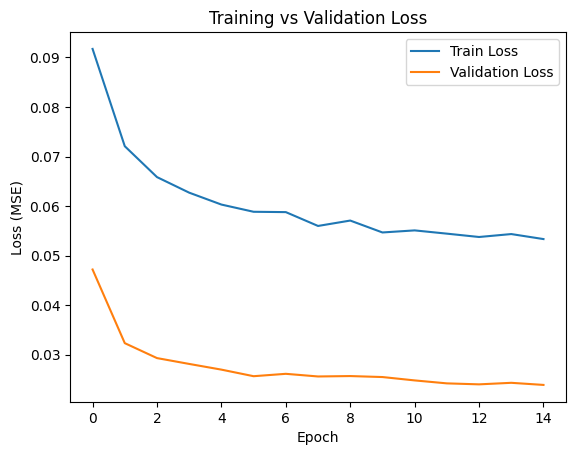

In [ ]:

epochs = 15  # Define the number of training epochs
training_pipeline(model_conv3DLSTM_v2, train_generator, val_generator, train_ids, val_ids, epochs, batch_size=8)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


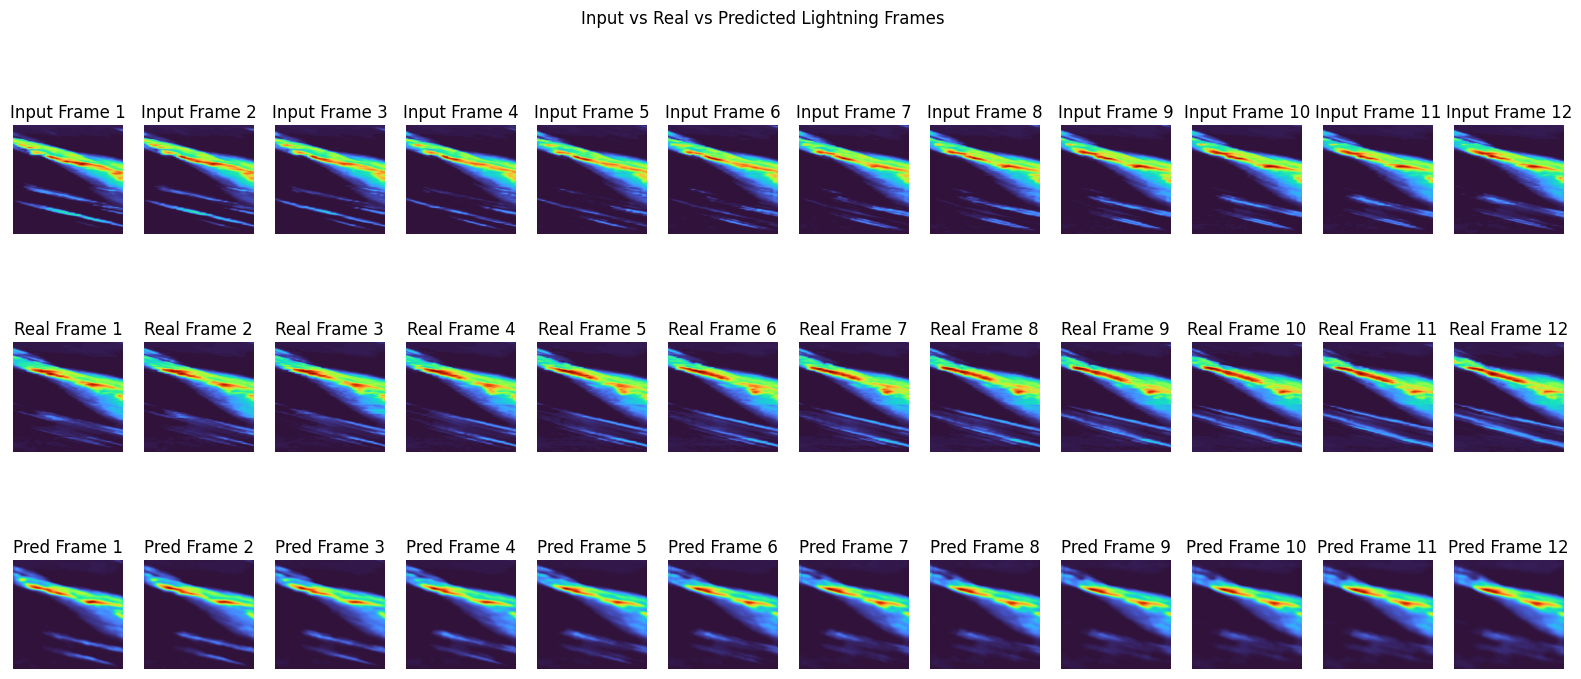

In [ ]:
model_conv3DLSTM_v2 = tf.keras.models.load_model("/content/drive/MyDrive/models/conv3DLSTM_lightning_prediction.keras", compile=False)
prediction_pipeline(model_conv3DLSTM_v2, test_generator)

- Sharper Predictions:
- More Accurate Motion Tracking:
- Better Feature Retention

### Add Residual Connections in ConvLSTM Layers X

- Connect x2 to x6 to recover mid-level spatial features.
- Connect x1 to x7 to restore early fine-grained details.

In [ ]:
input_shape = (12, 384, 384, 1)
input_layer = Input(shape=input_shape)

# Encoding (Downsampling)
x1 = Conv3D(16, (5, 5, 5), padding='same', activation='relu', strides=(1, 1, 1))(input_layer)  # Preserve spatial resolution
x2 = Conv3D(32, (5, 5, 5), padding='same', activation='relu', strides=(1, 2, 2))(x1)  # Downsample spatially
x3 = Conv3D(64, (3, 3, 3), padding='same', activation='relu', strides=(1, 2, 2))(x2)  # Further downsampling
x3 = Dropout(0.3)(x3)

# ConvLSTM for temporal sequence learning
x4 = ConvLSTM2D(64, (3, 3), padding="same", return_sequences=True, activation="relu")(x3)
x4 = Dropout(0.3)(x4)

x5 = ConvLSTM2D(32, (3, 3), padding="same", return_sequences=True, activation="relu")(x4)
x5 = Dropout(0.2)(x5)

# Decoding (Upsampling with Skip Connections)
x6 = Conv3DTranspose(32, (3, 3, 3), strides=(1, 2, 2), padding='same', activation='relu')(x5)
x6 = Add()([x6, x2])  # Skip connection from earlier encoding layer
x6 = Dropout(0.2)(x6)

x7 = Conv3DTranspose(16, (3, 3, 3), strides=(1, 2, 2), padding='same', activation='relu')(x6)
x7 = Add()([x7, x1])  # Skip connection from first encoding layer
x7 = Dropout(0.2)(x7)

# Output layer: Predicts 12 frames
output_layer = Conv3D(1, (1, 1, 1), padding='same', activation='linear')(x7)

# Define model
model_conv3DLSTM_v3 = Model(inputs=input_layer, outputs=output_layer)

model_conv3DLSTM_v3.summary()

Model: "functional_191"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8             │ (None, 12, 384, 384,   │              0 │ -                      │
│ (InputLayer)              │ 1)                     │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv3d_32 (Conv3D)        │ (None, 12, 384, 384,   │          2,016 │ input_layer_8[0][0]    │
│                           │ 16)                    │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv3d_33 (Conv3D)        │ (None, 12, 192, 192,   │         64,032 │ conv3d_32[0][0]        │
│                           │ 32)                    │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv3d_34 (Conv3D)        │ (None, 12, 96, 96, 64) │         55,360 │ conv3d_33[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_40 (Dropout)      │ (None, 12, 96, 96, 64) │              0 │ conv3d_34[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_lstm2d_16            │ (None, 12, 96, 96, 64) │        295,168 │ dropout_40[0][0]       │
│ (ConvLSTM2D)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_41 (Dropout)      │ (None, 12, 96, 96, 64) │              0 │ conv_lstm2d_16[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_lstm2d_17            │ (None, 12, 96, 96, 32) │        110,720 │ dropout_41[0][0]       │
│ (ConvLSTM2D)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_42 (Dropout)      │ (None, 12, 96, 96, 32) │              0 │ conv_lstm2d_17[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv3d_transpose_16       │ (None, 12, 192, 192,   │         27,680 │ dropout_42[0][0]       │
│ (Conv3DTranspose)         │ 32)                    │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_2 (Add)               │ (None, 12, 192, 192,   │              0 │ conv3d_transpose_16[0… │
│                           │ 32)                    │                │ conv3d_33[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_43 (Dropout)      │ (None, 12, 192, 192,   │              0 │ add_2[0][0]            │
│                           │ 32)                    │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv3d_transpose_17       │ (None, 12, 384, 384,   │         13,840 │ dropout_43[0][0]       │
│ (Conv3DTranspose)         │ 16)                    │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_3 (Add)               │ (None, 12, 384, 384,   │              0 │ conv3d_transpose_17[0… │
│                           │ 16)                    │                │ conv3d_32[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_44 (Dropout) 

 Total params: 568,833 (2.17 MB)

 Trainable params: 568,833 (2.17 MB)

 Non-trainable params: 0 (0.00 B)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

Epoch 1/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 105s 1s/step - loss: 0.0834 - mae: 0.0360 - val_loss: 0.0378 - val_mae: 0.0165
Epoch 2/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - loss: 0.0754 - mae: 0.0325 - val_loss: 0.0372 - val_mae: 0.0163
Epoch 3/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 87s 1s/step - loss: 0.0747 - mae: 0.0323 - val_loss: 0.0369 - val_mae: 0.0162
Epoch 4/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - loss: 0.0745 - mae: 0.0322 - val_loss: 0.0371 - val_mae: 0.0162
Epoch 5/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - loss: 0.0740 - mae: 0.0320 - val_loss: 0.0380 - val_mae: 0.0163
Epoch 6/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - loss: 0.0740 - mae: 0.0320 - val_loss: 0.0369 - val_mae: 0.0161
Epoch 7/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - loss: 0.0739 - mae: 0.0319 - val_loss: 0.0364 - val_mae: 0.0161
Epoch 8/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - loss: 0.0739 - mae: 0.0318 - val_loss: 0.0374 - val_mae: 0.0162
Epoch 9/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - loss: 0.0736 - mae:

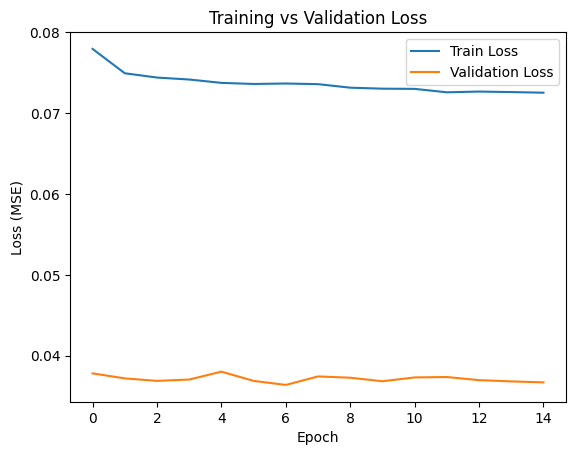

In [ ]:
epochs = 15  # Define the number of training epochs
training_pipeline(model_conv3DLSTM_v3, train_generator, val_generator, train_ids, val_ids, epochs, batch_size=8)

This improved stability but model might not be learning complex motion well.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


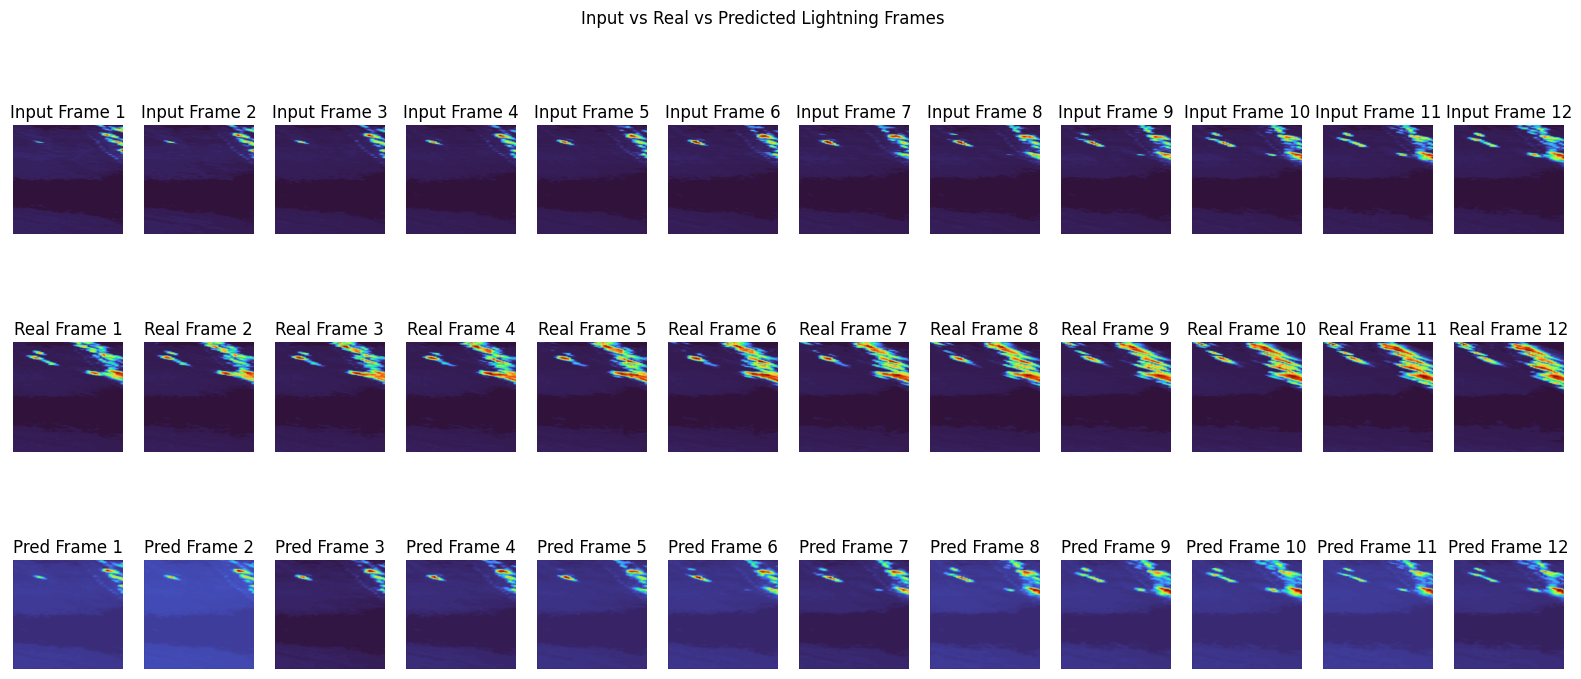

In [ ]:
model_conv3DLSTM_v3 = tf.keras.models.load_model("/content/drive/MyDrive/models/conv3DLSTM_lightning_prediction.keras", compile=False)
prediction_pipeline(model_conv3DLSTM_v3, test_generator)

Since the image quality is evidently reduced I will not use skip connections. I think model is not deep enough to make much of a difference.

### Attention blocks X

I asked chatgpt for help and it suggesting uisng  Squeeze-and-Excitation (SE) Attention Blocks.

- After ConvLSTM layers and conv layers.
- Improves motion continuity across frames.

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv3D, ConvLSTM2D, Conv3DTranspose, Dropout, Multiply, GlobalAveragePooling3D, Dense, Reshape, Input

# Define Attention Block (Squeeze-and-Excitation)
def attention_block(input_tensor):
    """Squeeze-and-Excitation (SE) block for spatial-temporal feature refinement."""
    se = GlobalAveragePooling3D()(input_tensor)  # Global pooling
    se = Dense(units=input_tensor.shape[-1] // 2, activation='relu')(se)  # Dimensionality reduction
    se = Dense(units=input_tensor.shape[-1], activation='sigmoid')(se)  # Scaling
    se = Reshape((1, 1, 1, input_tensor.shape[-1]))(se)  # Reshape to match input tensor
    return Multiply()([input_tensor, se])  # Multiply input by attention weights

# Define input shape (batch, depth, height, width, channels)
input_shape = (12, 384, 384, 1)
input_layer = Input(shape=input_shape)

# Encoding (Downsampling) with Attention
x1 = Conv3D(16, (5, 5, 5), padding='same', activation='relu', strides=(1, 1, 1))(input_layer)
x1 = attention_block(x1)

x2 = Conv3D(32, (5, 5, 5), padding='same', activation='relu', strides=(1, 2, 2))(x1)
x2 = attention_block(x2)

x3 = Conv3D(64, (3, 3, 3), padding='same', activation='relu', strides=(1, 2, 2))(x2)
x3 = attention_block(x3)
x3 = Dropout(0.3)(x3)

# ConvLSTM for Temporal Sequence Learning with Attention
x4 = Conv3D(64, (3, 3, 3), padding='same', activation='relu')(x3)  # Replaced first ConvLSTM with Conv3D
x4 = ConvLSTM2D(64, (3, 3), padding="same", return_sequences=True, activation="relu")(x4)
x4 = attention_block(x4)
x4 = Dropout(0.3)(x4)

x5 = ConvLSTM2D(32, (3, 3), padding="same", return_sequences=True, activation="relu")(x4)
x5 = attention_block(x5)
x5 = Dropout(0.2)(x5)

x6 = ConvLSTM2D(32, (3, 3), padding="same", return_sequences=True, activation="relu")(x5)  # Additional ConvLSTM layer
x6 = Dropout(0.2)(x6)

# Decoding (Upsampling with Attention)
x7 = Conv3DTranspose(32, (3, 3, 3), strides=(1, 2, 2), padding='same', activation='relu')(x6)
x7 = attention_block(x7)
x7 = Dropout(0.2)(x7)

x8 = Conv3DTranspose(16, (3, 3, 3), strides=(1, 2, 2), padding='same', activation='relu')(x7)
x8 = attention_block(x8)
x8 = Dropout(0.2)(x8)

# Output layer: Predicts 12 frames
output_layer = Conv3D(1, (1, 1, 1), padding='same', activation='linear')(x8)

# Define model
model_conv3DLSTM_v4 = Model(inputs=input_layer, outputs=output_layer)

# Show model summary
model_conv3DLSTM_v4.summary()

Model: "functional_192"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_15            │ (None, 12, 384, 384,   │              0 │ -                      │
│ (InputLayer)              │ 1)                     │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv3d_51 (Conv3D)        │ (None, 12, 384, 384,   │          2,016 │ input_layer_15[0][0]   │
│                           │ 16)                    │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling3d  │ (None, 16)             │              0 │ conv3d_51[0][0]        │
│ (GlobalAveragePooling3D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 8)              │            136 │ global_average_poolin… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 16)             │            144 │ dense[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ reshape (Reshape)         │ (None, 1, 1, 1, 16)    │              0 │ dense_1[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multiply (Multiply)       │ (None, 12, 384, 384,   │              0 │ conv3d_51[0][0],       │
│                           │ 16)                    │                │ reshape[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv3d_52 (Conv3D)        │ (None, 12, 192, 192,   │         64,032 │ multiply[0][0]         │
│                           │ 32)                    │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling3d… │ (None, 32)             │              0 │ conv3d_52[0][0]        │
│ (GlobalAveragePooling3D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_2 (Dense)           │ (None, 16)             │            528 │ global_average_poolin… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_3 (Dense)           │ (None, 32)             │            544 │ dense_2[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ reshape_1 (Reshape)       │ (None, 1, 1, 1, 32)    │              0 │ dense_3[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multiply_1 (Multiply)     │ (None, 12, 192, 192,   │              0 │ conv3d_52[0][0],       │
│                           │ 32)                    │                │ reshape_1[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv3d_53 (Conv3D)        │ (None, 12, 96, 96, 64) │         55,360 │ multiply_1[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling3d… │ (None, 64)             │              0 │ conv3d_53[0][0]        │
│ (GlobalAveragePooling3D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_4 (Dense)      

 Total params: 765,505 (2.92 MB)

 Trainable params: 765,505 (2.92 MB)

 Non-trainable params: 0 (0.00 B)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

Epoch 1/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - loss: 0.1485 - mae: 0.0573 - val_loss: 0.0891 - val_mae: 0.0256
Epoch 2/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - loss: 0.1180 - mae: 0.0482 - val_loss: 0.0569 - val_mae: 0.0232
Epoch 3/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - loss: 0.0861 - mae: 0.0383 - val_loss: 0.0382 - val_mae: 0.0166
Epoch 4/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - loss: 0.0697 - mae: 0.0321 - val_loss: 0.0391 - val_mae: 0.0197
Epoch 5/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - loss: 0.0661 - mae: 0.0313 - val_loss: 0.0330 - val_mae: 0.0148
Epoch 6/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - loss: 0.0635 - mae: 0.0291 - val_loss: 0.0323 - val_mae: 0.0142
Epoch 7/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - loss: 0.0604 - mae: 0.0280 - val_loss: 0.0318 - val_mae: 0.0154
Epoch 8/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - loss: 0.0616 - mae: 0.0284 - val_loss: 0.0300 - val_mae: 0.0141
Epoch 9/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - loss: 0.0582 - mae:

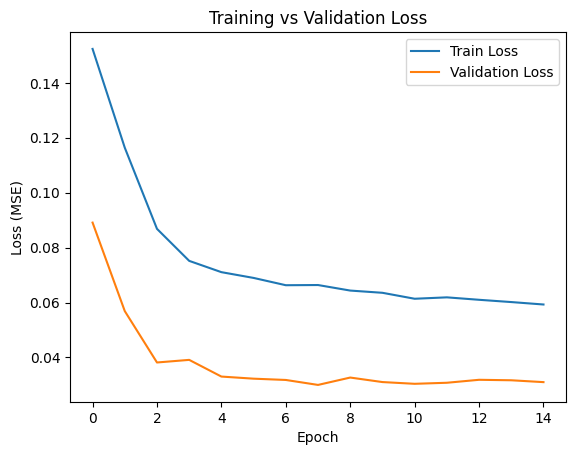

In [ ]:
epochs = 15  # Define the number of training epochs
training_pipeline(model_conv3DLSTM_v4, train_generator, val_generator, train_ids, val_ids, epochs, batch_size=8)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


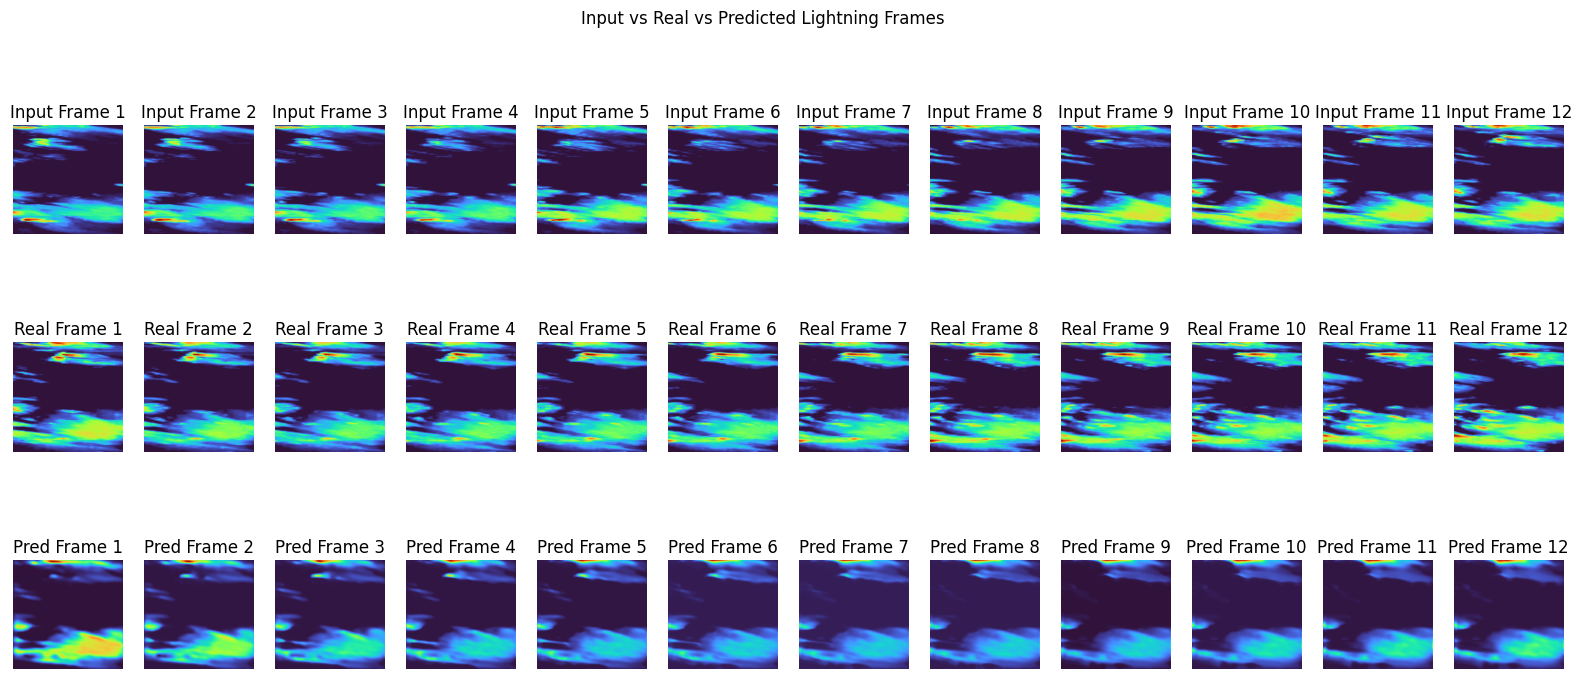

In [ ]:
model_conv3DLSTM_v4 = tf.keras.models.load_model("/content/drive/MyDrive/models/conv3DLSTM_lightning_prediction.keras", compile=False)
prediction_pipeline(model_conv3DLSTM_v4, test_generator)

If all spatial regions contribute equally, attention may not be beneficial. Attention forces for feature selection based on spatial patterns might be interfering with motion/frame-to-frame learning.

Let's try removing the attention block to the encoder and decoder bit.  

### BidirectionalConvLSTM2D X

In [ ]:
from tensorflow.keras.layers import Conv3D, ConvLSTM2D, Conv3DTranspose, Dropout, Bidirectional

# Define input shape (batch, depth, height, width, channels)
input_shape = (12, 384, 384, 1)

# Build Conv3D + Bidirectional ConvLSTM2D Model
model_conv3DLSTM_v5 = Sequential([
    # Encoding (Downsampling)
    Conv3D(16, (5, 5, 5), padding='same', activation='relu', strides=(1, 1, 1), input_shape=input_shape),
    Conv3D(32, (5, 5, 5), padding='same', activation='relu', strides=(1, 2, 2)),
    Conv3D(64, (3, 3, 3), padding='same', activation='relu', strides=(1, 2, 2)),
    Dropout(0.3),

    # Bidirectional ConvLSTM for Temporal Sequence Learning
    Bidirectional(ConvLSTM2D(64, (3, 3), padding="same", return_sequences=True, activation="relu")),
    Dropout(0.3),

    Bidirectional(ConvLSTM2D(32, (3, 3), padding="same", return_sequences=True, activation="relu")),
    Dropout(0.2),

    # Decoding (Upsampling)
    Conv3DTranspose(32, (3, 3, 3), strides=(1, 2, 2), padding='same', activation='relu'),
    Dropout(0.2),

    Conv3DTranspose(16, (3, 3, 3), strides=(1, 2, 2), padding='same', activation='relu'),
    Dropout(0.2),

    # Output layer: Predicts 12 frames
    Conv3D(1, (1, 1, 1), padding='same', activation='linear')
])

# Loss function = mse_ssim_loss
model_conv3DLSTM_v5.compile(optimizer="adam", loss=mse_ssim_loss(alpha=0.7, beta=0.3), metrics=["mae"])

# Show model summary
model_conv3DLSTM_v5.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv3d_74 (Conv3D)                   │ (None, 12, 384, 384, 16)    │           2,016 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_75 (Conv3D)                   │ (None, 12, 192, 192, 32)    │          64,032 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_76 (Conv3D)                   │ (None, 12, 96, 96, 64)      │          55,360 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_86 (Dropout)                 │ (None, 12, 96, 96, 64)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_2 (Bidirectional)      │ (None, 12, 96, 96, 128)     │         590,336 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_87 (Dropout)                 │ (None, 12, 96, 96, 128)     │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_3 (Bidirectional)      │ (None, 12, 96, 96, 64)      │         368,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_88 (Dropout)                 │ (None, 12, 96, 96, 64)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_transpose_32                  │ (None, 12, 192, 192, 32)    │          55,328 │
│ (Conv3DTranspose)                    │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_89 (Dropout)                 │ (None, 12, 192, 192, 32)    │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_transpose_33                  │ (None, 12, 384, 384, 16)    │          13,840 │
│ (Conv3DTranspose)                    │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_90 (Dropout)                 │ (None, 12, 384, 384, 16)    │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_77 (Conv3D)                   │ (None, 12, 384, 384, 1)     │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,149,825 (4.39 MB)

 Trainable params: 1,149,825 (4.39 MB)

 Non-trainable params: 0 (0.00 B)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

Epoch 1/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.0761 - mae: 0.0344Total valid (input, output) pairs available in dataset: 28880
80/80 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - loss: 0.0761 - mae: 0.0345 - val_loss: 0.0398 - val_mae: 0.0141
Epoch 2/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - loss: 0.0560 - mae: 0.0240 - val_loss: 0.0348 - val_mae: 0.0182
Epoch 3/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 87s 1s/step - loss: 0.1052 - mae: 0.0548 - val_loss: 0.0579 - val_mae: 0.0265
Epoch 4/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - loss: 0.0750 - mae: 0.0373 - val_loss: 0.0471 - val_mae: 0.0228
Epoch 5/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - loss: 0.0645 - mae: 0.0262 - val_loss: 0.0235 - val_mae: 0.0110
Epoch 6/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - loss: 0.0491 - mae: 0.0211 - val_loss: 0.0393 - val_mae: 0.0202
Epoch 7/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - loss: 0.0519 - mae: 0.0211 - val_loss: 0.0366 - val_mae: 0.0172
Epoch 8/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - loss: 0

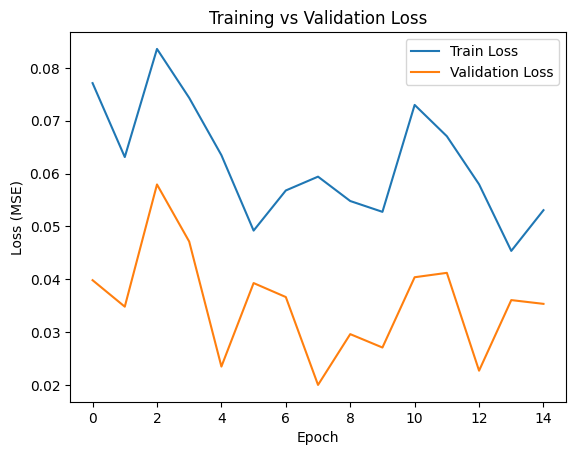

In [ ]:
epochs = 15  # Define the number of training epochs
training_pipeline(model_conv3DLSTM_v5, train_generator, val_generator, train_ids, val_ids, epochs, batch_size=8)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


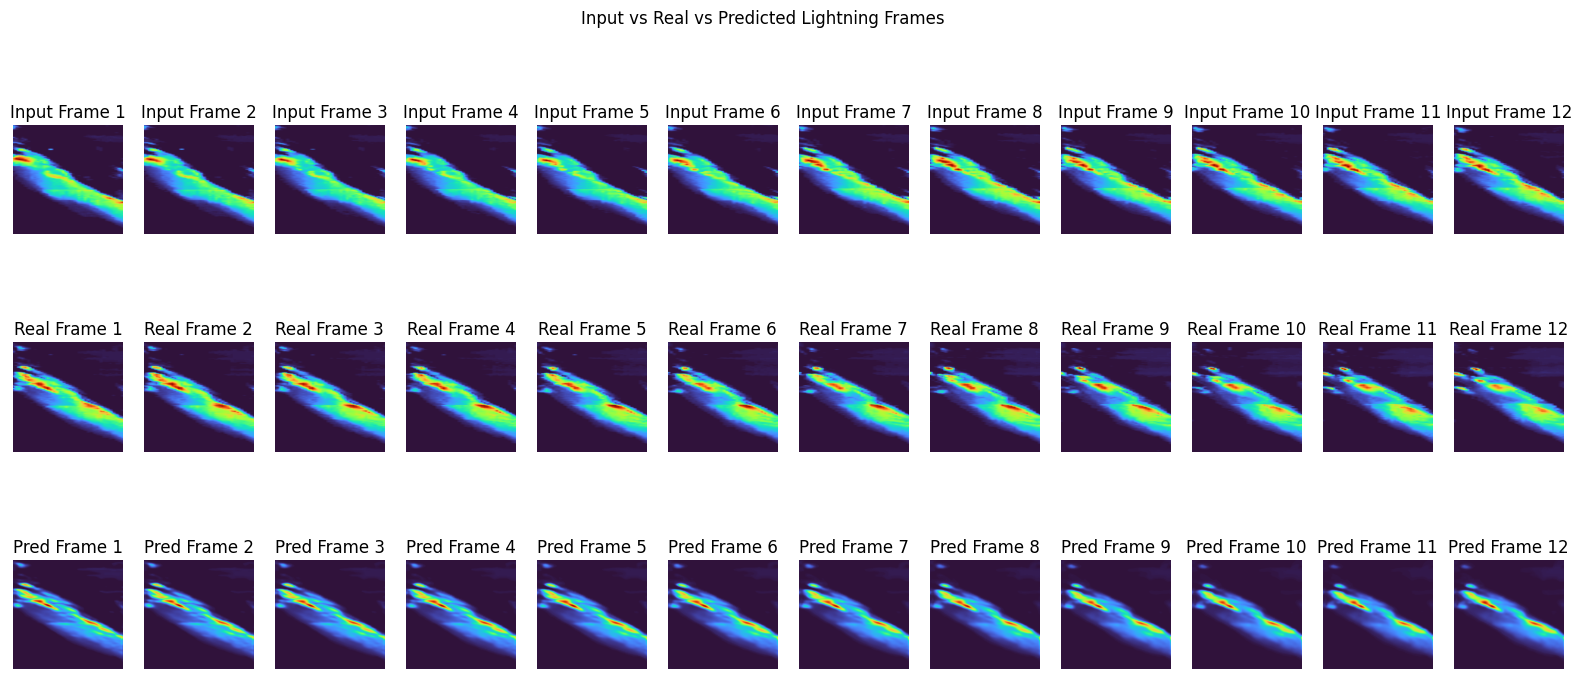

In [ ]:
model_conv3DLSTM_v5 = tf.keras.models.load_model("/content/drive/MyDrive/models/conv3DLSTM_lightning_prediction.keras", compile=False)
prediction_pipeline(model_conv3DLSTM_v5, test_generator)

### 4 convlstm layers -> YES

Improves temporal modeling for long-range dependencies.

In [49]:
# Define input shape (batch, depth, height, width, channels)
input_shape = (12, 384, 384, 1)

# Build Conv3D + ConvLSTM2D Model
model_conv3DLSTM_v6 = Sequential([

    Conv3D(16, (5, 5, 5), padding='same', activation='relu', strides=(1, 1, 1), input_shape=input_shape),

    Conv3D(32, (5, 5, 5), padding='same', activation='relu', strides=(1, 2, 2)),

    Conv3D(64, (3, 3, 3), padding='same', activation='relu', strides=(1, 2, 2)),

    Dropout(0.3),

    ConvLSTM2D(128, (3, 3), padding="same", return_sequences=True, activation="relu"),

    Dropout(0.3),

    ConvLSTM2D(64, (3, 3), padding="same", return_sequences=True, activation="relu"),

    Dropout(0.3),

    ConvLSTM2D(32, (3, 3), padding="same", return_sequences=True, activation="relu"),

    Dropout(0.2),

    ConvLSTM2D(32, (3, 3), padding="same", return_sequences=True, activation="relu"),  # Additional ConvLSTM layer

    Dropout(0.2),

    Conv3DTranspose(64, (3, 3, 3), strides=(1, 2, 2), padding='same', activation='relu'),  # Restore spatial dimensions
    Dropout(0.2),

    Conv3DTranspose(32, (3, 3, 3), strides=(1, 1, 1), padding='same', activation='relu'),  # Keep spatial features
    Dropout(0.2),

    Conv3DTranspose(16, (3, 3, 3), strides=(1, 2, 2), padding='same', activation='relu'),  # Restore full spatial resolution

    Dropout(0.2),

    Conv3D(1, (1, 1, 1), padding='same', activation='linear')
])

# Loss function = mse_ssim_loss
model_conv3DLSTM_v6.compile(optimizer="adam", loss=mse_ssim_loss(alpha=0.7, beta=0.3), metrics=["mae"])


# Show model summary
model_conv3DLSTM_v6.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv3d_24 (Conv3D)                   │ (None, 12, 384, 384, 16)    │           2,016 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_25 (Conv3D)                   │ (None, 12, 192, 192, 32)    │          64,032 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_26 (Conv3D)                   │ (None, 12, 96, 96, 64)      │          55,360 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_58 (Dropout)                 │ (None, 12, 96, 96, 64)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_lstm2d_34 (ConvLSTM2D)          │ (None, 12, 96, 96, 128)     │         885,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_59 (Dropout)                 │ (None, 12, 96, 96, 128)     │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_lstm2d_35 (ConvLSTM2D)          │ (None, 12, 96, 96, 64)      │         442,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_60 (Dropout)                 │ (None, 12, 96, 96, 64)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_lstm2d_36 (ConvLSTM2D)          │ (None, 12, 96, 96, 32)      │         110,720 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_61 (Dropout)                 │ (None, 12, 96, 96, 32)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_lstm2d_37 (ConvLSTM2D)          │ (None, 12, 96, 96, 32)      │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_62 (Dropout)                 │ (None, 12, 96, 96, 32)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_transpose_18                  │ (None, 12, 192, 192, 64)    │          55,360 │
│ (Conv3DTranspose)                    │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_63 (Dropout)                 │ (None, 12, 192, 192, 64)    │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_transpose_19                  │ (None, 12, 192, 192, 32)    │          55,328 │
│ (Conv3DTranspose)                    │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_64 (Dropout)                 │ (None, 12, 192, 192, 32)    │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_transpose_20                  │ (None, 12, 384, 384, 16)    │          13,840 │
│ (Conv3DTranspose)                    │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_65 (Dropout)                 │ (None, 12, 384, 384, 16)    │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_27 (Conv3D)                   │ (None, 12, 384, 384, 1)     │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,758,401 (6.71 MB)

 Trainable params: 1,758,401 (6.71 MB)

 Non-trainable params: 0 (0.00 B)

Mounted at /content/drive


0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

Epoch 1/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 355s 3s/step - loss: 0.1600 - mae: 0.0598 - val_loss: 0.1031 - val_mae: 0.0478
Epoch 2/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 202s 3s/step - loss: 0.1034 - mae: 0.0479 - val_loss: 0.0822 - val_mae: 0.0457
Epoch 3/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 197s 2s/step - loss: 0.0902 - mae: 0.0466 - val_loss: 0.0669 - val_mae: 0.0374
Epoch 4/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 191s 2s/step - loss: 0.0832 - mae: 0.0413 - val_loss: 0.0764 - val_mae: 0.0395
Epoch 5/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 173s 2s/step - loss: 0.0780 - mae: 0.0354 - val_loss: 0.0507 - val_mae: 0.0264
Epoch 6/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 165s 2s/step - loss: 0.0686 - mae: 0.0296 - val_loss: 0.0531 - val_mae: 0.0260
Epoch 7/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 166s 2s/step - loss: 0.0719 - mae: 0.0320 - val_loss: 0.0518 - val_mae: 0.0266
Epoch 8/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 167s 2s/step - loss: 0.0664 - mae: 0.0283 - val_loss: 0.0466 - val_mae: 0.0242
Epoch 9/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 167s 2s/step - loss: 0.063

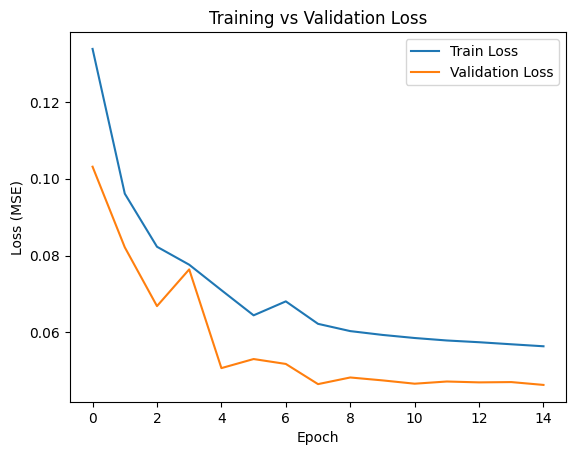

In [15]:
epochs = 15  # Define the number of training epochs
training_pipeline(model_conv3DLSTM_v6, train_generator, val_generator, train_ids, val_ids, epochs, batch_size=8)

Oscillations, especially in the earlier epochs.
This can be due to:
- High Learning Rate? Model makes large updates, causing fluctuations.
- ConvLSTM layers suffer from unstable gradients.
- Too much randomness in neuron activations.

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


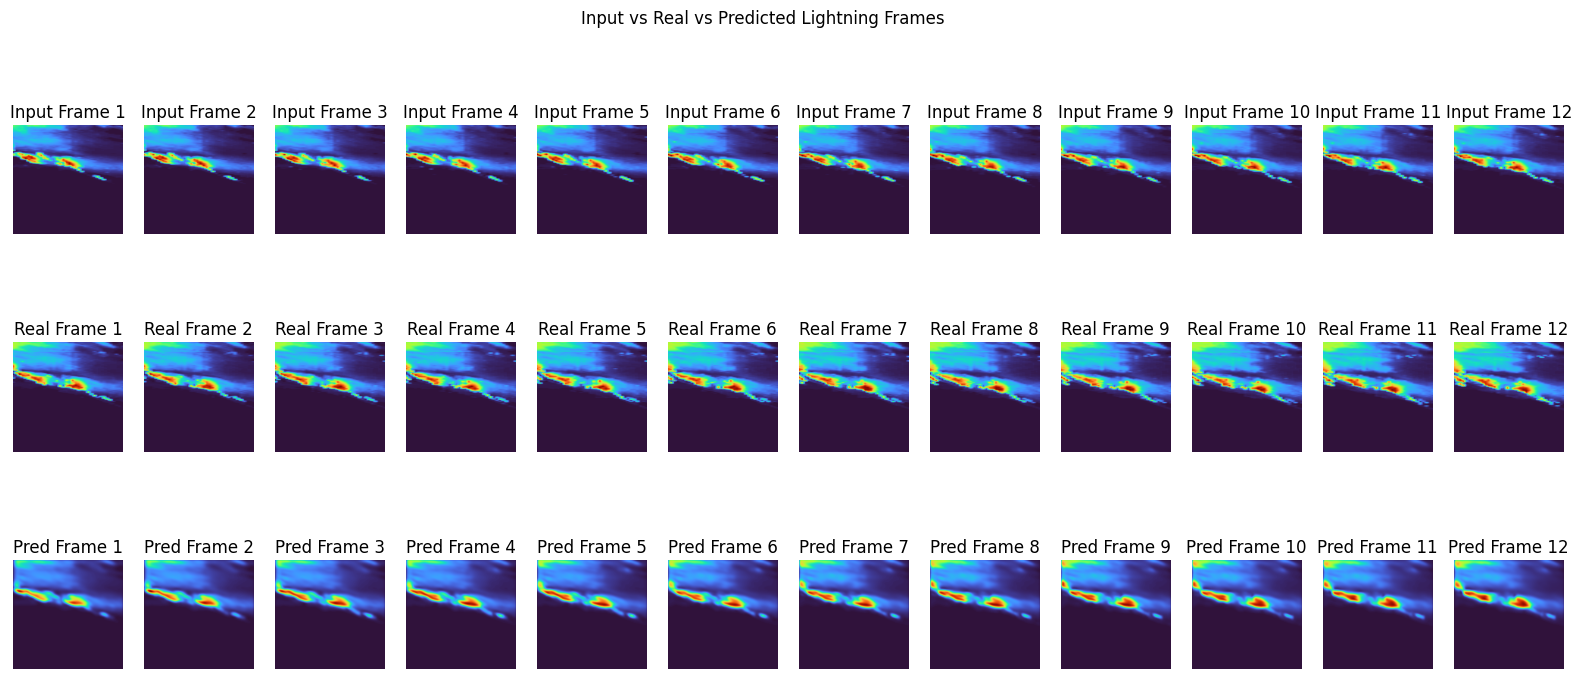

In [19]:
model_conv3DLSTM_v6 = tf.keras.models.load_model("/content/drive/MyDrive/models/conv3DLSTM_lightning_prediction.keras", compile=False)
prediction_pipeline(model_conv3DLSTM_v6, val_generator)

### Reducing lr dynamically X

In [34]:
def train_model(model, train_generator, val_generator, epochs, train_steps, val_steps, initial_lr=3e-3):
    """Trains the model with a dynamic learning rate and tqdm progress bar."""

    optimizer = Adam(learning_rate=initial_lr)

    lr_scheduler = ReduceLROnPlateau(
        monitor='val_loss', factor=0.7, patience=5, min_lr=5e-5, cooldown=2, verbose=1
    )

    model.compile(optimizer=optimizer, loss=mse_ssim_loss(alpha=0.7, beta=0.3), metrics=["mae"])

    train_steps = len(train_ids) // 8
    val_steps = len(val_ids) // 8

    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=epochs,
        steps_per_epoch=train_steps,
        validation_steps=val_steps,
        callbacks=[TqdmCallback(), lr_scheduler]
    )
    return history



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

Epoch 1/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 229s 3s/step - loss: 0.1344 - mae: 0.0570 - val_loss: 0.1159 - val_mae: 0.0494 - learning_rate: 0.0030
Epoch 2/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 201s 3s/step - loss: 0.1310 - mae: 0.0569 - val_loss: 0.1160 - val_mae: 0.0494 - learning_rate: 0.0030
Epoch 3/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 199s 3s/step - loss: 0.1310 - mae: 0.0569 - val_loss: 0.1160 - val_mae: 0.0494 - learning_rate: 0.0030
Epoch 4/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 192s 2s/step - loss: 0.1311 - mae: 0.0569 - val_loss: 0.1160 - val_mae: 0.0494 - learning_rate: 0.0030
Epoch 5/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 173s 2s/step - loss: 0.1311 - mae: 0.0569 - val_loss: 0.1160 - val_mae: 0.0494 - learning_rate: 0.0030
Epoch 6/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.1311 - mae: 0.0570
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.002100000018253922.
80/80 ━━━━━━━━━━━━━━━━━━━━ 177s 2s/step - loss: 0.1311 - mae: 0.0569 - val_loss: 0.1160 - val_mae: 0.0494 - learning_rate: 0.0030
Epoch 7/15
8

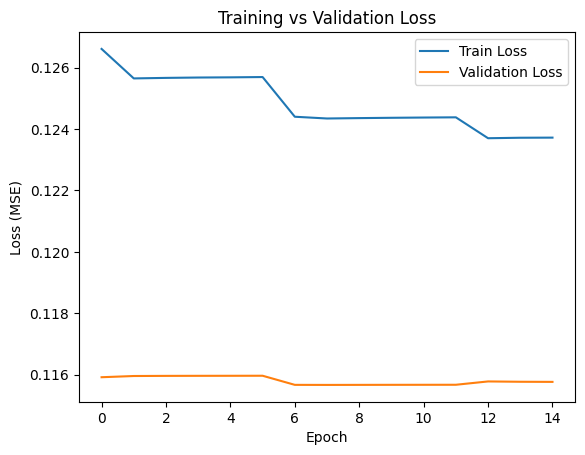

In [35]:
training_pipeline(model_conv3DLSTM_v6, train_generator, val_generator, train_ids, val_ids, epochs, batch_size=8)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


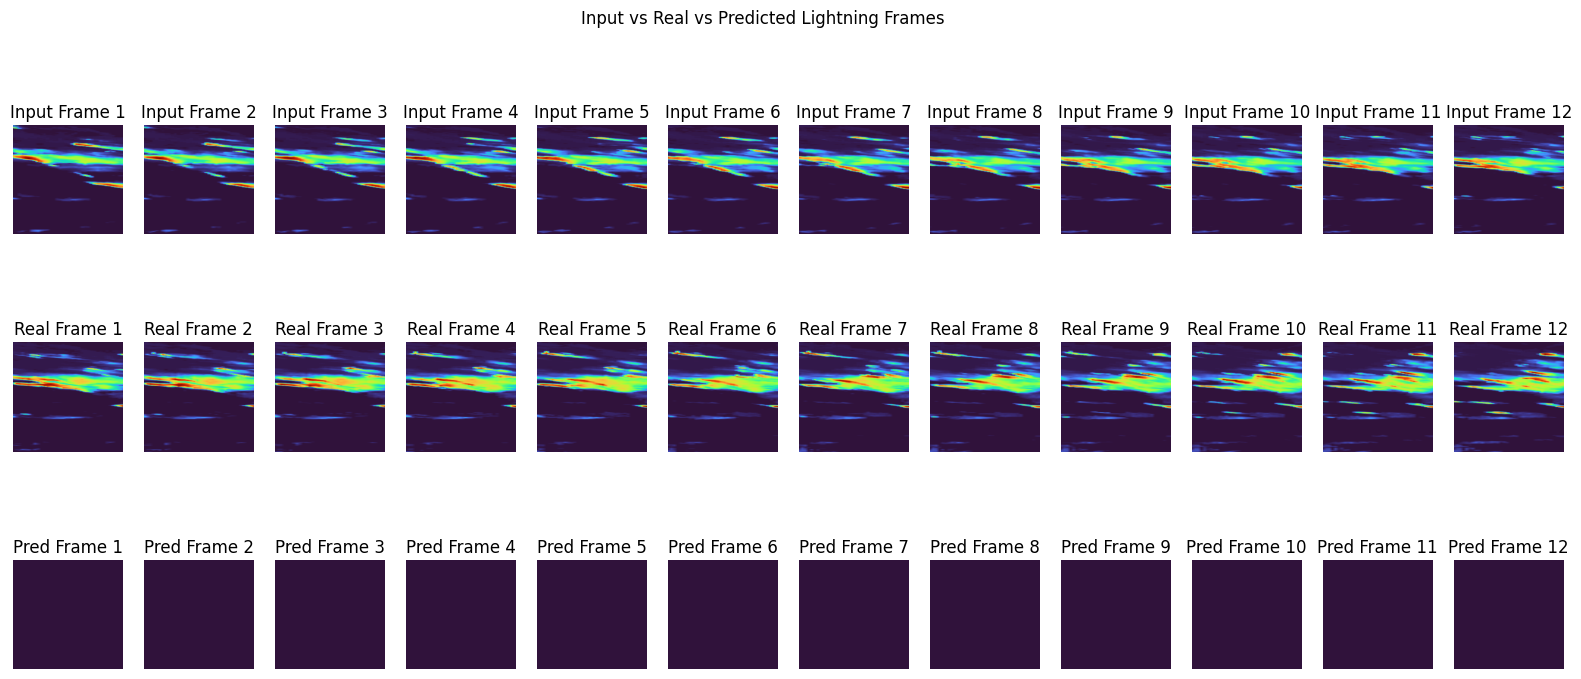

In [38]:
model_conv3DLSTM_v6 = tf.keras.models.load_model("/content/drive/MyDrive/models/conv3DLSTM_lightning_prediction.keras", compile=False)
prediction_pipeline(model_conv3DLSTM_v6, val_generator)

Worst yet.

### Even more convlstm layers -> X(crash memory)

In [22]:
# Define input shape (batch, depth, height, width, channels)
input_shape = (12, 384, 384, 1)

# Build Conv3D + ConvLSTM2D Model with 10 ConvLSTM Layers
model_conv3DLSTM_v7 = Sequential([

    Conv3D(16, (5, 5, 5), padding='same', activation='relu', strides=(1, 1, 1), input_shape=input_shape),

    Conv3D(32, (5, 5, 5), padding='same', activation='relu', strides=(1, 2, 2)),

    Conv3D(64, (3, 3, 3), padding='same', activation='relu', strides=(1, 2, 2)),

    Dropout(0.3),

    ConvLSTM2D(128, (3, 3), padding="same", return_sequences=True, activation="relu"),

    Dropout(0.3),

    ConvLSTM2D(128, (3, 3), padding="same", return_sequences=True, activation="relu"),

    Dropout(0.3),

    ConvLSTM2D(64, (3, 3), padding="same", return_sequences=True, activation="relu"),

    Dropout(0.3),

    ConvLSTM2D(64, (3, 3), padding="same", return_sequences=True, activation="relu"),

    Dropout(0.3),

    ConvLSTM2D(32, (3, 3), padding="same", return_sequences=True, activation="relu"),

    Dropout(0.2),

    ConvLSTM2D(32, (3, 3), padding="same", return_sequences=True, activation="relu"),

    Dropout(0.2),

    ConvLSTM2D(16, (3, 3), padding="same", return_sequences=True, activation="relu"),

    Dropout(0.2),

    ConvLSTM2D(16, (3, 3), padding="same", return_sequences=True, activation="relu"),

    Dropout(0.2),

    Conv3DTranspose(64, (3, 3, 3), strides=(1, 2, 2), padding='same', activation='relu'),  # Restore spatial dimensions

    Dropout(0.2),

    Conv3DTranspose(32, (3, 3, 3), strides=(1, 1, 1), padding='same', activation='relu'),  # Keep spatial features

    Dropout(0.2),

    Conv3DTranspose(16, (3, 3, 3), strides=(1, 2, 2), padding='same', activation='relu'),  # Restore full spatial resolution

    Dropout(0.2),

    # Output layer: Predicts 12 frames
    Conv3D(1, (1, 1, 1), padding='same', activation='linear')
])

# Optimizer with Gradient Clipping
# optimizer = Adam(learning_rate=1e-3, clipnorm=1.0)

# Learning Rate Scheduler
# lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)


model_conv3DLSTM_v7.compile(optimizer="adam", loss=mse_ssim_loss(alpha=0.7, beta=0.3), metrics=["mae"])

# Show Model Summary
model_conv3DLSTM_v7.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv3d_12 (Conv3D)                   │ (None, 12, 384, 384, 16)    │           2,016 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_13 (Conv3D)                   │ (None, 12, 192, 192, 32)    │          64,032 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_14 (Conv3D)                   │ (None, 12, 96, 96, 64)      │          55,360 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_30 (Dropout)                 │ (None, 12, 96, 96, 64)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_lstm2d_18 (ConvLSTM2D)          │ (None, 12, 96, 96, 128)     │         885,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_31 (Dropout)                 │ (None, 12, 96, 96, 128)     │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_lstm2d_19 (ConvLSTM2D)          │ (None, 12, 96, 96, 128)     │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_32 (Dropout)                 │ (None, 12, 96, 96, 128)     │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_lstm2d_20 (ConvLSTM2D)          │ (None, 12, 96, 96, 64)      │         442,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_33 (Dropout)                 │ (None, 12, 96, 96, 64)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_lstm2d_21 (ConvLSTM2D)          │ (None, 12, 96, 96, 64)      │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_34 (Dropout)                 │ (None, 12, 96, 96, 64)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_lstm2d_22 (ConvLSTM2D)          │ (None, 12, 96, 96, 32)      │         110,720 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_35 (Dropout)                 │ (None, 12, 96, 96, 32)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_lstm2d_23 (ConvLSTM2D)          │ (None, 12, 96, 96, 32)      │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_36 (Dropout)                 │ (None, 12, 96, 96, 32)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_lstm2d_24 (ConvLSTM2D)          │ (None, 12, 96, 96, 16)      │          27,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_37 (Dropout)                 │ (None, 12, 96, 96, 16)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_lstm2d_25 (ConvLSTM2D)          │ (None, 12, 96, 96, 16)      │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_38 (Dropout)                 │ (None, 12, 96, 96, 16)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_transpose_9 (Conv3DTranspose) │ (None, 12, 192, 192, 64)    │          27,712 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 3,252,289 (12.41 MB)

 Trainable params: 3,252,289 (12.41 MB)

 Non-trainable params: 0 (0.00 B)

Out of memory.

## Explainability

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


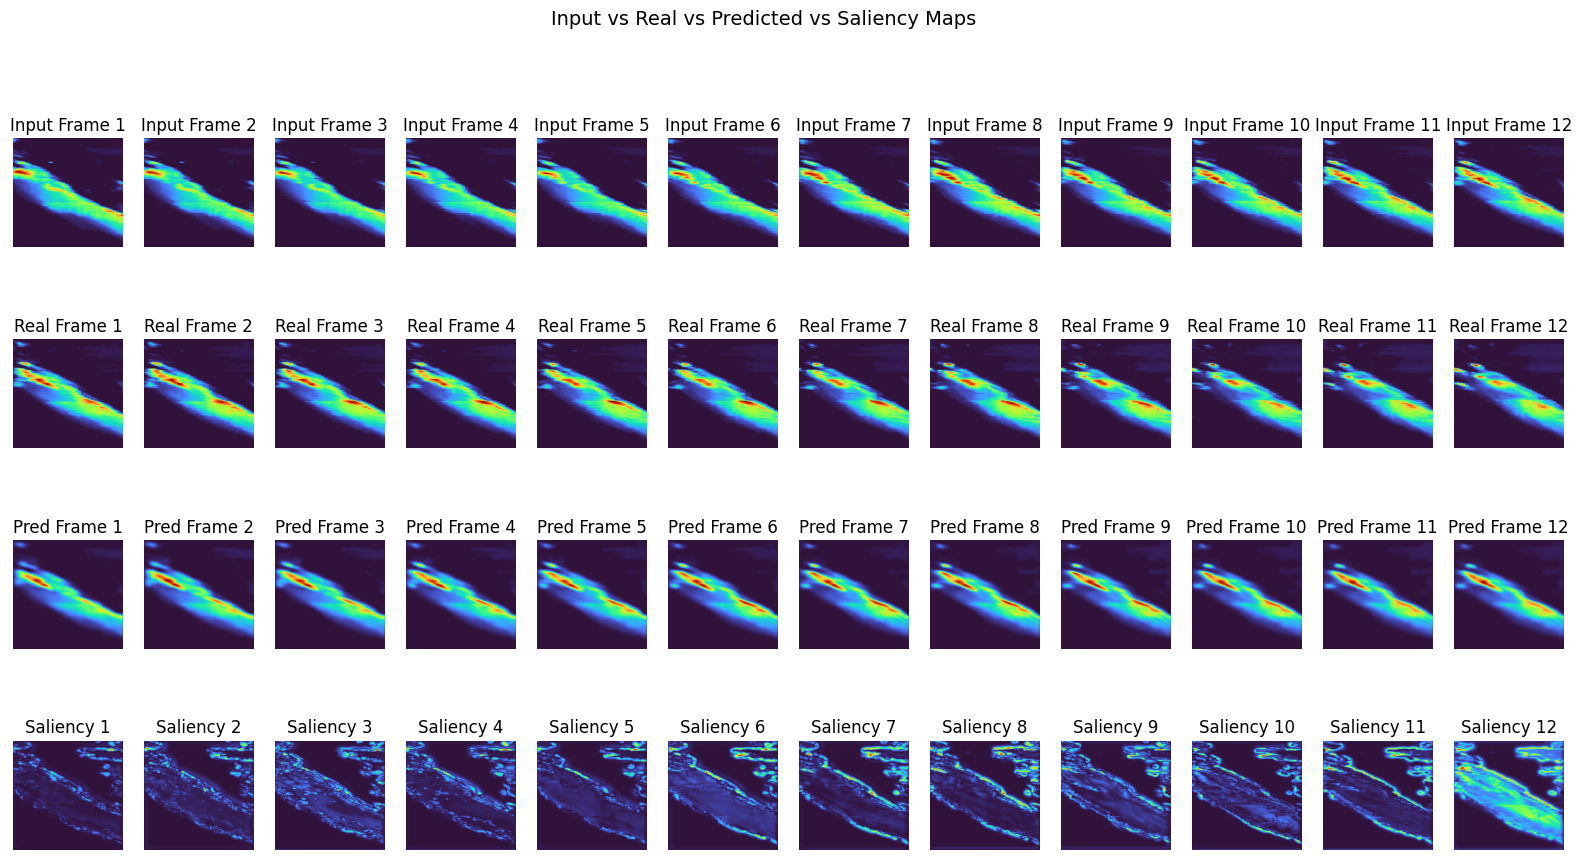

In [69]:
model = tf.keras.models.load_model("/content/drive/MyDrive/models/conv3DLSTM_lightning_prediction_v6.keras", compile=False)
prediction_pipeline_2(model, test_generator)

The results provide a clear comparison between the input frames, ground truth (real) frames, predicted frames, and their respective saliency maps. The predicted frames closely follow the real frames, indicating that the model has learned meaningful spatial and temporal patterns from the input sequence. However, slight discrepancies in finer details suggest areas where prediction accuracy could be improved. The saliency maps highlight the regions in the input frames that had the most influence on the predicted outputs. These maps show strong activation along the bright lightning structures, confirming that the model is focusing on relevant spatial features rather than noise. Notably, the saliency intensity varies across frames, suggesting that some frames contribute more to the predictions than others. This analysis helps in assessing both model reliability and interpretability, potentially guiding improvements such as refining attention mechanisms or incorporating additional spatiotemporal constraints.

Since the saliency maps show meaningful attention on key regions, the issue of the attention layer is likely not in missing dependencies—but rather where, how, and when attention is applied.

## Outlook

While U-Nets and CNN-LSTMs provide a solid foundation for spatiotemporal forecasting, they come with inherent limitations. U-Nets, although powerful for spatial feature extraction, struggle with long-term temporal dependencies as they treat time implicitly, leading to drifting predictions in later frames. CNN-LSTMs, on the other hand, explicitly model temporal dependencies but are computationally expensive, prone to vanishing gradients, and can struggle with capturing long-range dependencies effectively.

Recent research suggests alternative architectures that could further improve performance. Transformer-based models, such as Video Vision Transformers (ViTs) or Temporal Attention Networks, can capture global temporal dependencies more effectively than recurrent models. Additionally, Diffusion Models and GAN-based architectures have shown promise in generating high-resolution, temporally consistent video frames by learning latent distributions. Hybrid approaches like ConvLSTM + Transformer hybrids could also enhance temporal learning while retaining localized spatial feature extraction.https://www.researchgate.net/publication/373987811_Comprehensive_Transformer-Based_Model_Architecture_for_Real-World_Storm_Prediction

Morevoer, another idea would be to explore other methods of data augmentation, temporally-wise and spatially-wise, suchas rotations and time series interpolation since we are given frames that are 5 minutes apart.
